# Retrieving Data from HDF5 Output Files

This guide walks through the complete workflow for:

1. **Running batch scenarios** using `run_examplar_batch_scenario.py`
2. **Extracting tables** from the resulting `.hd5` files using `extract_tables_from_hd5_file.py`
3. **Reading and combining** extracted CSVs into Polars DataFrames using `read_tables_from_extracted_files.py`

---

## Background

The ABM writes simulation output into HDF5 files (`.hd5`) named `disease_X_Y.hd5`, where `X` and `Y` are the start and end years of the simulation. These files can contain multiple data groups (e.g. `prevalence`, `disease_byage`, `vaccination_delivered`), each with one or more datasets. They also store all run parameters as attributes on the `/params` node.

Working with HDF5 directly requires `h5py` and low-level indexing. The two helper scripts automate the extraction and loading into tidy DataFrames.

## 1. Setup — paths and imports

In [42]:
import os, sys
from pathlib import Path

# Strategy 1 — VS Code injects __vsc_ipynb_file__ with the notebook's absolute path.
# This notebook lives at <repo_root>/src/pneu_abm/code_guide/, so repo_root is 3 levels up.
# This is the most reliable strategy: it is anchored to THIS file, not to cwd or sys.path
# (cwd drifts after os.chdir; sys.path may contain stale editable-install entries from
#  other clones/backups of the repo).
repo_root = None
try:
    _nb_path = Path(__vsc_ipynb_file__.replace("file://", "")).resolve()  # type: ignore[name-defined]
    _candidate = _nb_path.parents[3]   # code_guide → pneu_abm → src → repo_root
    if (_candidate / "pyproject.toml").exists():
        repo_root = str(_candidate)
except NameError:
    pass   # Not running inside VS Code — fall through to Strategy 2

# Strategy 2 — walk up from cwd (works on a clean first run from the notebook's directory).
if repo_root is None:
    _candidate = Path(os.getcwd()).resolve()
    while True:
        if (_candidate / "pyproject.toml").exists():
            repo_root = str(_candidate)
            break
        _parent = _candidate.parent
        if _parent == _candidate:
            break
        _candidate = _parent

if repo_root is None:
    raise RuntimeError(
        f"Cannot find repo root (pyproject.toml not found).\n"
        f"cwd={os.getcwd()!r}"
    )

src_path = os.path.join(repo_root, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

os.chdir(repo_root)
print("Repo root:", repo_root)
print("Cwd     :", os.getcwd())


Repo root: /Users/tellioglun/Documents/abm_pneu_model
Cwd     : /Users/tellioglun/Documents/abm_pneu_model


In [43]:
import polars as pl
import numpy as np

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(12)

polars.config.Config

---

## 2. Run batch scenarios

The script `run_examplar_batch_scenario.py` uses `parq` to run multiple parameter combinations in parallel. Here we configure **2 runs** of a single vaccine scenario so the demonstration finishes quickly.

Output is written to `src/pneu_abm/output/base_results/`.

In [44]:
import parq

import pneu_abm  # noqa
from pneu_abm.data.scenario_configs.base_params import p
from pneu_abm.utils.param_combo import ParamComboIt
from pneu_abm.run_scenarios.disease_model import new_go_single

# -----------------------------------------------------------------
# Base configuration
# Use absolute paths so parq worker processes (which are spawned fresh
# on macOS and don't inherit os.chdir()) can find all files.
# -----------------------------------------------------------------
p["resource_prefix"] = os.path.join(repo_root, "src", "pneu_abm", "data") + os.sep
p["prefix"]          = os.path.join(repo_root, "src", "pneu_abm", "output", "base_results")
p["pop_prefix"]      = p["prefix"]
p["epi_prefix"]      = p["prefix"]
p["overwrite"]       = True
p["years"]           = [0, 1]   # simulate 1 year (fast demo)
p["read_population"] = False
p["save_population"] = True
p["num_runs"]        = 2       # 2 stochastic replicates per scenario

# -----------------------------------------------------------------
# Parameter sweep — here we run one vaccine scenario
# To run multiple scenarios, add more values to the list
# e.g. 'values': ["vaccine_configs/vaccine_list.csv", "vaccine_configs/vaccine_list_v2.csv"]
# -----------------------------------------------------------------
sweep_params = [
    {"name": "vaccine_list", "values": ["vaccine_configs/vaccine_list.csv"]},
]

param_combos = list(ParamComboIt(p, sweep_params))

all_combos = []
for i, combo in enumerate(param_combos):
    combo["seed_no"] = i
    all_combos.append(combo)
    print("Scenario output dir:", combo["prefix"])

job_inputs = [(combo,) for combo in all_combos]


Scenario output dir: /Users/tellioglun/Documents/abm_pneu_model/src/pneu_abm/output/base_results/params_vaccine_list=vaccine_configs/vaccine_list.csv/seed_0
Scenario output dir: /Users/tellioglun/Documents/abm_pneu_model/src/pneu_abm/output/base_results/params_vaccine_list=vaccine_configs/vaccine_list.csv/seed_1


In [45]:
# Run 2 worker processes in parallel (one per scenario combination)
import time
t0 = time.time()
parq.run(new_go_single, job_inputs, n_proc=2, results=False)
print(f"Finished in {time.time() - t0:.1f} s")

Finished in 46.2 s


After the run completes, the output directory looks like this:

```
src/pneu_abm/output/base_results/
└── params_vaccine_list=vaccine_configs/vaccine_list.csv/
    ├── seed_0/
    │   └── disease_0_1.hd5
    └── seed_1/
        └── disease_0_1.hd5
```

Each `.hd5` contains groups like `prevalence`, `disease_byage`, `vaccination_delivered`, etc., plus a `/params` node holding all run parameters as attributes.

---

## 3. Extract tables with `extract_tables_from_hd5_file.py`

This script walks every sub-folder under the named output folder, finds all `disease_X_Y.hd5` files, and writes CSVs **alongside** each HDF5 file:

| CSV file | Contents |
|---|---|
| `params_0_1.csv` | All `/params` attributes as a single-row table |
| `prevalence_base_data_0_1.csv` | Prevalence time-series |
| `disease_byage_base_data_0_1.csv` | Disease burden by age group |
| `vaccination_delivered_base_data_0_1.csv` | Vaccines delivered per timestep |
| … | All other datasets found in the HDF5 hierarchy |

> **List-valued columns** (e.g. per-age-group arrays stored as one array per row) are serialised as JSON strings so they survive the CSV round-trip and can be decoded automatically by the companion read script.

In [46]:
from pneu_abm.plot_outputs.extract_tables_from_hd5_file import extract_hd5, main as extract_main

# Extract all tables from every .hd5 file under 'base_results'
extract_main(folder_name="base_results")

Found 2 HDF5 file(s) under 'base_results'

  /Users/tellioglun/Documents/abm_pneu_model/src/pneu_abm/output/base_results/params_vaccine_list=vaccine_configs/vaccine_list.csv/seed_1/disease_0_1.hd5
    params  -> /Users/tellioglun/Documents/abm_pneu_model/src/pneu_abm/output/base_results/params_vaccine_list=vaccine_configs/vaccine_list.csv/seed_1/params_0_1.csv
    disease_byage/base_data                  -> disease_byage_base_data_0_1.csv
    disease_byvaccine/base_data              -> disease_byvaccine_base_data_0_1.csv
    population/age_dists                     -> population_age_dists_0_1.csv
    population/base_data                     -> population_base_data_0_1.csv
    prevalence/base_data                     -> prevalence_base_data_0_1.csv
    prevalencebyage/base_data                -> prevalencebyage_base_data_0_1.csv
    vaccination/base_data                    -> vaccination_base_data_0_1.csv
    vaccination_delivered/base_data          -> vaccination_delivered_base_data_0_

### Flexibility: extract a single file

You can also target a single `.hd5` file directly using `extract_hd5()`:

In [47]:
single_file = (
    "src/pneu_abm/output/base_results/"
    "params_vaccine_list=vaccine_configs/vaccine_list.csv/"
    "seed_0/disease_0_1.hd5"
)
extract_hd5(os.path.join(repo_root, single_file))


  /Users/tellioglun/Documents/abm_pneu_model/src/pneu_abm/output/base_results/params_vaccine_list=vaccine_configs/vaccine_list.csv/seed_0/disease_0_1.hd5
    params  -> /Users/tellioglun/Documents/abm_pneu_model/src/pneu_abm/output/base_results/params_vaccine_list=vaccine_configs/vaccine_list.csv/seed_0/params_0_1.csv
    disease_byage/base_data                  -> disease_byage_base_data_0_1.csv
    disease_byvaccine/base_data              -> disease_byvaccine_base_data_0_1.csv
    population/age_dists                     -> population_age_dists_0_1.csv
    population/base_data                     -> population_base_data_0_1.csv
    prevalence/base_data                     -> prevalence_base_data_0_1.csv
    prevalencebyage/base_data                -> prevalencebyage_base_data_0_1.csv
    vaccination/base_data                    -> vaccination_base_data_0_1.csv
    vaccination_delivered/base_data          -> vaccination_delivered_base_data_0_1.csv


---

## 4. Read and combine tables with `read_tables_from_extracted_files.py`

Once the CSVs exist, the read script combines matching files across all seeds and scenario sub-folders into **one big Polars DataFrame**, automatically adding columns that identify which sub-folder each row came from.

### 4a. Read a single table

`read_extracted_tables(folder_name, table_name)` collects all files matching `<table_name>_<X>_<Y>.csv` and returns a combined DataFrame.

In [48]:
from pneu_abm.plot_outputs.read_tables_from_extracted_files import (
    read_extracted_tables,
    read_save_all_combined_tables,
)

prev_df = read_extracted_tables("base_results", "prevalence_base_data")
print(prev_df.shape)
prev_df.head()

Found 2 CSV file(s) for table 'prevalence_base_data'
(106, 14)


t,infected_population,infected_frac_0_2_year_olds,strain_list,infected_frac_65_100_year_olds,infected_frac_0_4_year_olds,…,infected_frac_0_10_year_olds,infected_frac_40_100_year_olds,infected_frac_40_64_year_olds,subfolder_1,subfolder_2,subfolder_3
i64,f64,f64,list[f64],f64,f64,…,f64,f64,f64,str,str,str
0,0.124289,0.241357,"[0.003127, 0.00059, … 0.013719]",0.120216,0.191213,…,0.151618,0.119937,0.119778,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
1,0.103953,0.232608,"[0.002629, 0.000473, … 0.011472]",0.071955,0.183385,…,0.143079,0.086148,0.100837,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
2,0.101214,0.233422,"[0.002536, 0.000475, … 0.011272]",0.052564,0.184885,…,0.146462,0.075105,0.099348,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
3,0.099153,0.234007,"[0.002482, 0.00047, … 0.011037]",0.039195,0.185264,…,0.148492,0.067124,0.097972,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
4,0.098043,0.236051,"[0.002398, 0.000441, … 0.010986]",0.029893,0.187188,…,0.150744,0.062137,0.096968,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""


Notice the automatically added `subfolder_N` columns — these encode the parameter combination and seed that produced each row:

| Column | Example value | Meaning |
|---|---|---|
| `subfolder_1` | `params_vaccine_list=vaccine_configs` | Top-level scenario folder |
| `subfolder_2` | `vaccine_list.csv` | Vaccine config used |
| `subfolder_3` | `seed_0` | Stochastic replicate index |

In [49]:
# Inspect the subfolder columns
subfolder_cols = [c for c in prev_df.columns if c.startswith("subfolder")]
prev_df.select(subfolder_cols).unique()

subfolder_1,subfolder_2,subfolder_3
str,str,str
"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_0"""


### 4b. List-type columns are decoded automatically

Columns that store per-row arrays (e.g. `strain_list` — one prevalence value per strain) are stored as JSON strings in the CSV and decoded back to proper Polars `List` columns when read.

In [50]:
# Show which columns are List-type
list_cols = [c for c in prev_df.columns if isinstance(prev_df[c].dtype, pl.List)]
print("List columns:", list_cols)

# Example: strain_list holds one float per serotype per timestep
prev_df.select("t", "strain_list").head(3)

List columns: ['strain_list']


t,strain_list
i64,list[f64]
0,"[0.003127, 0.00059, … 0.013719]"
1,"[0.002629, 0.000473, … 0.011472]"
2,"[0.002536, 0.000475, … 0.011272]"


### 4c. Disease burden by age group

In [51]:
disease_df = read_extracted_tables("base_results", "disease_byage_base_data")
print(disease_df.shape)
disease_df.select(["t", "run_no", "cap_per_100k", "ipd_per_100k",
                   "no_of_cap_per_age_group", "subfolder_3"]).head(5)

Found 2 CSV file(s) for table 'disease_byage_base_data'
(200, 29)


t,run_no,cap_per_100k,ipd_per_100k,no_of_cap_per_age_group,subfolder_3
i64,i64,i64,i64,list[i64],str
0,0,11,1,"[0, 0, … 0]","""seed_1"""
0,1,9,1,"[0, 1, … 0]","""seed_1"""
0,2,9,1,"[0, 0, … 0]","""seed_1"""
0,3,8,1,"[0, 0, … 0]","""seed_1"""
0,4,8,0,"[0, 1, … 0]","""seed_1"""


### 4d. Vaccination delivered

In [52]:
vacc_df = read_extracted_tables("base_results", "vaccination_delivered_base_data")
print(vacc_df.shape)
vacc_df.head()

Found 2 CSV file(s) for table 'vaccination_delivered_base_data'
(0, 7)


t,vaccine_type,no_delivered,total_inds,subfolder_1,subfolder_2,subfolder_3
i64,i64,i64,i64,str,str,str


---

## 5. Save and read back a single combined table

`main()` reads + saves in one call. The result is written to `output/<folder_name>/<table_name>.csv`.

In [53]:
from pneu_abm.plot_outputs.read_tables_from_extracted_files import main as read_main

read_main(folder_name="base_results", table_name="prevalence_base_data")

Found 2 CSV file(s) for table 'prevalence_base_data'

Combined DataFrame: 106 rows × 14 columns
shape: (5, 14)
┌─────┬────────┬───────┬───────┬───────┬───────┬───┬───────┬───────┬───────┬───────┬───────┬───────┐
│ t   ┆ infect ┆ infec ┆ strai ┆ infec ┆ infec ┆ … ┆ infec ┆ infec ┆ infec ┆ subfo ┆ subfo ┆ subfo │
│ --- ┆ ed_pop ┆ ted_f ┆ n_lis ┆ ted_f ┆ ted_f ┆   ┆ ted_f ┆ ted_f ┆ ted_f ┆ lder_ ┆ lder_ ┆ lder_ │
│ i64 ┆ ulatio ┆ rac_0 ┆ t     ┆ rac_6 ┆ rac_0 ┆   ┆ rac_0 ┆ rac_4 ┆ rac_4 ┆ 1     ┆ 2     ┆ 3     │
│     ┆ n      ┆ _2_ye ┆ ---   ┆ 5_100 ┆ _4_ye ┆   ┆ _10_y ┆ 0_100 ┆ 0_64_ ┆ ---   ┆ ---   ┆ ---   │
│     ┆ ---    ┆ ar_ol ┆ list[ ┆ _year ┆ ar_ol ┆   ┆ ear_o ┆ _year ┆ year_ ┆ str   ┆ str   ┆ str   │
│     ┆ f64    ┆ ds    ┆ f64]  ┆ _olds ┆ ds    ┆   ┆ lds   ┆ _olds ┆ olds  ┆       ┆       ┆       │
│     ┆        ┆ ---   ┆       ┆ ---   ┆ ---   ┆   ┆ ---   ┆ ---   ┆ ---   ┆       ┆       ┆       │
│     ┆        ┆ f64   ┆       ┆ f64   ┆ f64   ┆   ┆ f64   ┆ f64   ┆ f64   ┆     

t,infected_population,infected_frac_0_2_year_olds,strain_list,infected_frac_65_100_year_olds,infected_frac_0_4_year_olds,…,infected_frac_0_10_year_olds,infected_frac_40_100_year_olds,infected_frac_40_64_year_olds,subfolder_1,subfolder_2,subfolder_3
i64,f64,f64,list[f64],f64,f64,…,f64,f64,f64,str,str,str
0,0.124289,0.241357,"[0.003127, 0.00059, … 0.013719]",0.120216,0.191213,…,0.151618,0.119937,0.119778,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
1,0.103953,0.232608,"[0.002629, 0.000473, … 0.011472]",0.071955,0.183385,…,0.143079,0.086148,0.100837,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
2,0.101214,0.233422,"[0.002536, 0.000475, … 0.011272]",0.052564,0.184885,…,0.146462,0.075105,0.099348,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
3,0.099153,0.234007,"[0.002482, 0.00047, … 0.011037]",0.039195,0.185264,…,0.148492,0.067124,0.097972,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
4,0.098043,0.236051,"[0.002398, 0.000441, … 0.010986]",0.029893,0.187188,…,0.150744,0.062137,0.096968,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
5,0.097192,0.235895,"[0.002334, 0.000419, … 0.010917]",0.023616,0.18746,…,0.152866,0.058112,0.09612,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
6,0.096919,0.236809,"[0.002374, 0.000419, … 0.010904]",0.019426,0.189407,…,0.154747,0.055464,0.095668,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
7,0.096803,0.235902,"[0.002381, 0.000414, … 0.010871]",0.016137,0.190041,…,0.156331,0.053498,0.095367,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
8,0.096448,0.236236,"[0.002399, 0.000409, … 0.010793]",0.013935,0.191245,…,0.15683,0.051923,0.094674,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""


In [54]:
# Read the saved flat CSV back — List columns are stored as JSON strings
saved_path = "src/pneu_abm/output/base_results/prevalence_base_data.csv"
saved_df = pl.read_csv(saved_path)
print(saved_df.dtypes)
saved_df.head(3)

[Int64, Float64, Float64, String, Float64, Float64, Float64, Float64, Float64, Float64, Float64, String, String, String]


t,infected_population,infected_frac_0_2_year_olds,strain_list,infected_frac_65_100_year_olds,infected_frac_0_4_year_olds,…,infected_frac_0_10_year_olds,infected_frac_40_100_year_olds,infected_frac_40_64_year_olds,subfolder_1,subfolder_2,subfolder_3
i64,f64,f64,str,f64,f64,…,f64,f64,f64,str,str,str
0,0.124289,0.241357,"""[0.003127, 0.00058999999999999…",0.120216,0.191213,…,0.151618,0.119937,0.119778,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
1,0.103953,0.232608,"""[0.0026290614250712497, 0.0004…",0.071955,0.183385,…,0.143079,0.086148,0.100837,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
2,0.101214,0.233422,"""[0.002536191695321236, 0.00047…",0.052564,0.184885,…,0.146462,0.075105,0.099348,"""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""


> **Note:** When you read the flat CSV back, list columns appear as JSON strings again. Pass it through `read_extracted_tables()` or `_decode_list_columns()` if you need them as proper list-type columns in memory.

---

## 6. Save all tables at once with `read_save_all_combined_tables()`

Instead of specifying a table name, this function discovers **every** extracted table in the folder and saves them all to `output/<folder_name>/`.

In [55]:
all_tables = read_save_all_combined_tables("base_results")
print("\nTables saved:", list(all_tables.keys()))

Found 8 table(s) under 'base_results': ['disease_byage_base_data', 'disease_byvaccine_base_data', 'population_age_dists', 'population_base_data', 'prevalence_base_data', 'prevalencebyage_base_data', 'vaccination_base_data', 'vaccination_delivered_base_data']
Found 2 CSV file(s) for table 'disease_byage_base_data'
  disease_byage_base_data: 200 rows × 29 cols  -> /Users/tellioglun/Documents/abm_pneu_model/src/pneu_abm/output/base_results/disease_byage_base_data.csv
Found 2 CSV file(s) for table 'disease_byvaccine_base_data'
  disease_byvaccine_base_data: 200 rows × 24 cols  -> /Users/tellioglun/Documents/abm_pneu_model/src/pneu_abm/output/base_results/disease_byvaccine_base_data.csv
Found 2 CSV file(s) for table 'population_age_dists'
  population_age_dists: 4 rows × 5 cols  -> /Users/tellioglun/Documents/abm_pneu_model/src/pneu_abm/output/base_results/population_age_dists.csv
Found 2 CSV file(s) for table 'population_base_data'
  population_base_data: 4 rows × 6 cols  -> /Users/telliog

In [56]:
# The function returns a dict — you can access any table immediately
all_tables["prevalencebyage_base_data"].head()

t,total_inds_per_age_group,total_infecteds_per_age_group,total_infections_per_age_group,subfolder_1,subfolder_2,subfolder_3
i64,list[i64],list[i64],list[i64],str,str,str
0,"[12170, 11879, … 78]","[2979, 2864, … 8]","[2979, 2864, … 8]","""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
1,"[12203, 11880, … 75]","[2831, 2797, … 6]","[2845, 2809, … 6]","""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
2,"[12202, 11899, … 75]","[2806, 2770, … 5]","[2830, 2790, … 5]","""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
3,"[12231, 11893, … 74]","[2828, 2738, … 4]","[2864, 2772, … 4]","""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""
4,"[12237, 11914, … 76]","[2854, 2770, … 2]","[2888, 2807, … 2]","""params_vaccine_list=vaccine_co…","""vaccine_list.csv""","""seed_1"""


---

## 7. Quick analysis example — overall prevalence by seed

Using the combined prevalence table, compute mean total prevalence over time, grouped by stochastic replicate.

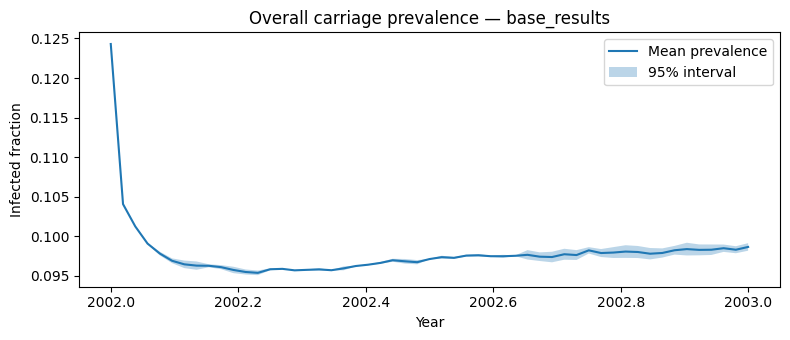

In [57]:
import matplotlib.pyplot as plt

t_per_year = 52  # weekly timesteps
start_year = 2002

prev_agg = (
    prev_df
    .with_columns(
        (pl.lit(start_year) + pl.col("t") / t_per_year).alias("year")
    )
    .group_by("t", "year")
    .agg(
        prev_mean = pl.col("infected_population").mean(),
        prev_lo   = pl.col("infected_population").quantile(0.025),
        prev_hi   = pl.col("infected_population").quantile(0.975),
    )
    .sort("t")
)

fig, ax = plt.subplots(figsize=(8, 3.5))
years = prev_agg["year"].to_list()
ax.plot(years, prev_agg["prev_mean"].to_list(), label="Mean prevalence")
ax.fill_between(
    years,
    prev_agg["prev_lo"].to_list(),
    prev_agg["prev_hi"].to_list(),
    alpha=0.3, label="95% interval"
)
ax.set_xlabel("Year")
ax.set_ylabel("Infected fraction")
ax.set_title("Overall carriage prevalence — base_results")
ax.legend()
plt.tight_layout()
plt.show()

---

## 8. Flexibility summary

### `extract_tables_from_hd5_file.py`

| Use case | How |
|---|---|
| Extract all files under a folder | `extract_main(folder_name="base_results")` |
| Extract a single `.hd5` file | `extract_hd5("/absolute/path/to/disease_0_1.hd5")` |
| Run from terminal | `python extract_tables_from_hd5_file.py base_results` |
| Any nesting depth | Walks the entire directory tree automatically |

### `read_tables_from_extracted_files.py`

| Use case | How |
|---|---|
| Read one table into memory | `read_extracted_tables("base_results", "disease_byage_base_data")` |
| Read + save one table | `read_main(folder_name="base_results", table_name="prevalence_base_data")` |
| Read + save **all** tables | `read_save_all_combined_tables("base_results")` |
| Save to custom path | `read_main(..., output="/my/path/result.csv")` |
| Run from terminal (single table) | `python read_tables_from_extracted_files.py base_results prevalence_base_data` |
| List columns | Decoded automatically to `List[Float64]` / `List[Int64]`; re-encoded to JSON when saved to CSV |